# Implementación de LSTM para detección y predicción de anomalías en tráfico de redes
**Dataset:** UNSW-NB15  
**Enfoque:** Clasificación supervisada binaria con **forecasting** (predicción N pasos adelante)  
**Arquitectura:** Stacked LSTM + BatchNormalization + Dropout + Dense(sigmoid)  
**Split:** Archivos 1+2 → Train/Val · Archivos 3+4 → Test


***Primera VERSIÓN: en la versión 2 se reajustó el desfase y desbalance de las clases en el train y test.***

## 1. Importaciones

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponible: []


## 2. Configuración general

In [ ]:
# ── Ruta al dataset UNSW-NB15 ───────────────────────────────────────────────
DATA_FOLDER = r"C:\Users\erik-\OneDrive\Documentos\GitHub\DETECCION-DE-ANOMALIAS\processed_data"

# Archivos 1+2 → entrenamiento | Archivos 3+4 → test
TRAIN_FILES = [
    "UNSW-NB15_1_processed.csv",
    "UNSW-NB15_2_processed.csv",
]
TEST_FILES = [
    "UNSW-NB15_3_processed.csv",
    "UNSW-NB15_4_processed.csv",
]

# ── Hiperparámetros ──────────────────────────────────────────────────────────
TIME_STEPS    = 10    # Pasos temporales de la ventana de contexto
FORECAST_N    = 5     # Pasos hacia el futuro que se desea predecir
                      # N=1 → próximo flujo | N=5 → 5 flujos adelante
BATCH_SIZE    = 256
EPOCHS        = 50
LEARNING_RATE = 1e-3
DROPOUT_RATE  = 0.3
LSTM1_UNITS   = 128
LSTM2_UNITS   = 64
VAL_RATIO     = 0.15  # Últimos 15% del train como validación (orden temporal)

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Features seleccionadas

In [6]:
SELECTED_FEATURES = [
    'dur',            # duración del flujo
    'sbytes',         # bytes enviados
    'dbytes',         # bytes recibidos
    'sttl',           # TTL fuente         | corr=0.837
    'dttl',           # TTL destino        | corr=0.454
    'Sload',          # bits/s fuente      | corr=0.254
    'Dload',          # bits/s destino     | corr=0.120
    'swin',           # ventana TCP fuente | corr=0.111
    'smeansz',        # tamaño medio paquete fuente
    'dmeansz',        # tamaño medio paquete destino | corr=0.137
    'Sjit',           # jitter fuente      | corr=0.075
    'Sintpkt',        # tiempo entre paquetes fuente
    'tcprtt',         # RTT TCP            | corr=0.331
    'ackdat',         # tiempo ACK-DATA    | corr=0.329
    'ct_state_ttl',   # conteo estado+TTL  | corr=0.743
    'ct_srv_dst',     # conteo conexiones al mismo servicio/destino
    'ct_dst_sport_ltm', # conteo conexiones al mismo dst+sport | corr=0.110
    'ct_dst_src_ltm', # conteo conexiones entre mismo src-dst  | corr=0.054
]

# NOTA: estos nombres deben coincidir EXACTAMENTE con las columnas que
# data_processing.ipynb guardó en los *_processed.csv.

TARGET   = 'Label'  # columna binaria 0/1, así se guardó en data_processing.ipynb
TIME_COL = 'time'   # columna de timestamp YA REAL (datetime), generada por
                     # data_processing.ipynb a partir de Stime + resample('1s').
                     # 'Stime' (Unix epoch) NO se conserva en los archivos
                     # procesados, por eso causaba el KeyError.

print(f"Features seleccionadas: {len(SELECTED_FEATURES)}")

Features seleccionadas: 18


## 4. Carga y preprocesamiento

In [7]:
def cargar_y_ordenar(files, folder):
    """Carga los *_processed.csv (ya generados por data_processing.ipynb,
    1 fila = 1 ventana de 1 segundo), los concatena y confirma el orden
    cronológico global."""
    dfs = []
    for f in files:
        path = os.path.join(folder, f)
        if os.path.exists(path):
            tmp = pd.read_csv(path, low_memory=False)
            tmp.columns = tmp.columns.str.strip()
            dfs.append(tmp)
            print(f"  Cargado: {f} — {len(tmp):,} filas")
        else:
            print(f"  [AVISO] No encontrado: {path}")
    df = pd.concat(dfs, ignore_index=True)

    # 'time' ya viene como datetime real guardado por data_processing.ipynb
    # (NO es Unix epoch, por eso no se usa unit='s' aquí); solo se convierte
    # de texto/objeto a datetime para poder ordenar correctamente.
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    return df


print("Cargando archivos de TRAIN (1+2)...")
df_train_raw = cargar_y_ordenar(TRAIN_FILES, DATA_FOLDER)

print(f"\nCargando archivos de TEST (3+4)...")
df_test_raw  = cargar_y_ordenar(TEST_FILES,  DATA_FOLDER)

# Validación temprana: si falta alguna columna esperada, avisa con claridad
# en vez de fallar más adelante con un KeyError críptico.
columnas_requeridas = SELECTED_FEATURES + [TARGET, TIME_COL]
for nombre, df in [("train", df_train_raw), ("test", df_test_raw)]:
    faltantes = [c for c in columnas_requeridas if c not in df.columns]
    if faltantes:
        raise KeyError(f"Faltan columnas en {nombre}: {faltantes}")

# Etiqueta binaria
for df in [df_train_raw, df_test_raw]:
    df[TARGET] = df[TARGET].astype(int)

print(f"\n{'─'*45}")
print(f"Train total : {len(df_train_raw):,} filas")
print(f"  Ataques   : {df_train_raw[TARGET].mean():.2%}")
print(f"Test total  : {len(df_test_raw):,} filas")
print(f"  Ataques   : {df_test_raw[TARGET].mean():.2%}")

Cargando archivos de TRAIN (1+2)...
  Cargado: UNSW-NB15_1_processed.csv — 28,466 filas
  Cargado: UNSW-NB15_2_processed.csv — 2,275,335 filas

Cargando archivos de TEST (3+4)...
  Cargado: UNSW-NB15_3_processed.csv — 18,911 filas
  Cargado: UNSW-NB15_4_processed.csv — 12,085 filas

─────────────────────────────────────────────
Train total : 2,303,801 filas
  Ataques   : 0.68%
Test total  : 30,996 filas
  Ataques   : 88.18%


In [8]:
for nombre, df in [("train", df_train_raw), ("test", df_test_raw)]:
    n_inf = np.isinf(df[SELECTED_FEATURES]).sum().sum()
    n_nan = df[SELECTED_FEATURES].isna().sum().sum()
    estado = "OK" if (n_inf == 0 and n_nan == 0) else "[AVISO] revisar data_processing.ipynb"
    print(f"{nombre}: infinitos={n_inf}, NaN={n_nan}  → {estado}")

# ── Split temporal Train → Train + Val (sin data leakage) ────────────────────
n_val      = int(len(df_train_raw) * VAL_RATIO)
df_val     = df_train_raw.iloc[-n_val:].copy()
df_train   = df_train_raw.iloc[:-n_val].copy()

print(f"Train efectivo : {len(df_train):,} filas | Ataques: {df_train[TARGET].mean():.2%}")
print(f"Validación     : {len(df_val):,} filas | Ataques: {df_val[TARGET].mean():.2%}")
print(f"Test           : {len(df_test_raw):,} filas | Ataques: {df_test_raw[TARGET].mean():.2%}")

# ── Escalado: ajuste solo en train, aplica a val y test ──────────────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(df_train[SELECTED_FEATURES])
X_val_sc   = scaler.transform(df_val[SELECTED_FEATURES])
X_test_sc  = scaler.transform(df_test_raw[SELECTED_FEATURES])

y_train = df_train[TARGET].values
y_val   = df_val[TARGET].values
y_test  = df_test_raw[TARGET].values

print("\nEscalado completado (RobustScaler ajustado en train)")

train: infinitos=0, NaN=0  → OK
test: infinitos=0, NaN=0  → OK
Train efectivo : 1,958,231 filas | Ataques: 0.33%
Validación     : 345,570 filas | Ataques: 2.68%
Test           : 30,996 filas | Ataques: 88.18%

Escalado completado (RobustScaler ajustado en train)


## 5. Construcción de secuencias con forecasting

In [9]:
def create_sequences(X, y, time_steps, forecast_n=1):
    """
    Construye secuencias deslizantes para forecasting.

    Parámetros
    ----------
    X          : array (n_muestras, n_features) — ya escalado
    y          : array (n_muestras,) — etiquetas binarias
    time_steps : tamaño de la ventana de contexto (pasos hacia atrás)
    forecast_n : cuántos pasos hacia el FUTURO predecir

    Lógica de la ventana
    --------------------
    Entrada : flujos [i ... i+time_steps-1]          (T pasos de contexto)
    Salida  : label  del flujo i+time_steps+forecast_n-1  (N pasos adelante)

    Ejemplo con time_steps=10, forecast_n=5:
      Entrada → flujos t-9 a t0  (ventana de 10)
      Salida  → label de t+5     (5 flujos en el futuro)
    """
    Xs, ys = [], []
    limit = len(X) - time_steps - forecast_n + 1
    for i in range(limit):
        Xs.append(X[i : i + time_steps])
        ys.append(y[i + time_steps + forecast_n - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


print(f"Configuración de forecasting:")
print(f"  Ventana de contexto : T = {TIME_STEPS} flujos hacia atrás")
print(f"  Horizonte de pred.  : N = {FORECAST_N} flujos hacia el futuro")
print()

X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train, TIME_STEPS, FORECAST_N)
X_val_seq,   y_val_seq   = create_sequences(X_val_sc,   y_val,   TIME_STEPS, FORECAST_N)
X_test_seq,  y_test_seq  = create_sequences(X_test_sc,  y_test,  TIME_STEPS, FORECAST_N)

print("Formas de los tensores:")
print(f"  X_train : {X_train_seq.shape}")
print(f"  X_val   : {X_val_seq.shape}")
print(f"  X_test  : {X_test_seq.shape}")
print(f"\nAataques en train_seq : {y_train_seq.mean():.2%}")
print(f"Ataques en test_seq   : {y_test_seq.mean():.2%}")

Configuración de forecasting:
  Ventana de contexto : T = 10 flujos hacia atrás
  Horizonte de pred.  : N = 5 flujos hacia el futuro

Formas de los tensores:
  X_train : (1958217, 10, 18)
  X_val   : (345556, 10, 18)
  X_test  : (30982, 10, 18)

Aataques en train_seq : 0.33%
Ataques en test_seq   : 88.22%


## 6. Pesos de clase (datos desbalanceados)

In [10]:
# Calcula pesos inversamente proporcionales a la frecuencia de cada clase
clases  = np.array([0, 1])
weights = compute_class_weight('balanced', classes=clases, y=y_train_seq)
class_weight = {0: weights[0], 1: weights[1]}

print("Pesos de clase:")
print(f"  Normal (0): {class_weight[0]:.4f}")
print(f"  Ataque (1): {class_weight[1]:.4f}")
print()
print("Esto penaliza más los errores en la clase minoritaria (ataques)")

Pesos de clase:
  Normal (0): 0.5017
  Ataque (1): 150.8642

Esto penaliza más los errores en la clase minoritaria (ataques)


## 7. Arquitectura del modelo LSTM

In [11]:
n_features = X_train_seq.shape[2]

model = Sequential([
    Input(shape=(TIME_STEPS, n_features)),

    # ── Capa LSTM 1: aprende dependencias temporales a largo plazo ────────
    LSTM(LSTM1_UNITS, return_sequences=True),
    BatchNormalization(),

    # ── Capa LSTM 2: resume la secuencia en un vector de contexto ─────────
    LSTM(LSTM2_UNITS, return_sequences=False),
    BatchNormalization(),

    # ── Regularización ────────────────────────────────────────────────────
    Dropout(DROPOUT_RATE),

    # ── Capa de salida: P(anomalía) ───────────────────────────────────────
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,505 (490.25 KB)

 Trainable params: 125,121 (488.75 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Entrenamiento

In [12]:
callbacks = [
    # Detiene el entrenamiento si val_loss no mejora en 7 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce el learning rate si val_loss se estanca
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val_seq),
    class_weight=class_weight,   # compensa el desbalance
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
7650/7650 ━━━━━━━━━━━━━━━━━━━━ 362s 47ms/step - accuracy: 0.9821 - auc: 0.9899 - loss: 0.1090 - precision: 0.1543 - recall: 0.9827 - val_accuracy: 0.9966 - val_auc: 0.9981 - val_loss: 0.0395 - val_precision: 0.8891 - val_recall: 0.9979 - learning_rate: 0.0010
Epoch 2/50
7650/7650 ━━━━━━━━━━━━━━━━━━━━ 244s 32ms/step - accuracy: 0.9818 - auc: 0.9962 - loss: 0.0501 - precision: 0.1532 - recall: 0.9935 - val_accuracy: 0.9967 - val_auc: 0.9977 - val_loss: 0.0287 - val_precision: 0.8931 - val_recall: 0.9979 - learning_rate: 0.0010
Epoch 3/50
7650/7650 ━━━━━━━━━━━━━━━━━━━━ 218s 29ms/step - accuracy: 0.9817 - auc: 0.9970 - loss: 0.0443 - precision: 0.1528 - recall: 0.9954 - val_accuracy: 0.9968 - val_auc: 0.9977 - val_loss: 0.0259 - val_precision: 0.8984 - val_recall: 0.9939 - learning_rate: 0.0010
Epoch 4/50
7650/7650 ━━━━━━━━━━━━━━━━━━━━ 216s 28ms/step - accuracy: 0.9815 - auc: 0.9972 - loss: 0.0418 - precision: 0.1520 - recall: 0.9972 - val_accuracy: 0.9969 - val_auc: 0.9977 - va

## 9. Umbral óptimo (optimización sobre val)

1350/1350 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step
Umbral óptimo (θ): 0.2024
F1 en validación:  0.9448


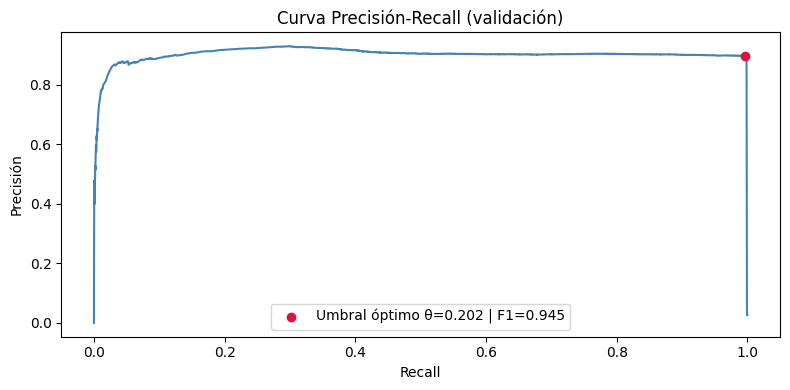

In [13]:
# Predicción de probabilidades sobre validación
y_val_prob = model.predict(X_val_seq, batch_size=BATCH_SIZE).ravel()

# Buscar el umbral θ que maximiza F1 sobre val
precisions, recalls, thresholds = precision_recall_curve(y_val_seq, y_val_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Umbral óptimo (θ): {BEST_THRESHOLD:.4f}")
print(f"F1 en validación:  {best_f1:.4f}")

# Curva Precisión-Recall
plt.figure(figsize=(8, 4))
plt.plot(recalls[:-1], precisions[:-1], color='steelblue', linewidth=1.5)
plt.scatter(recalls[best_idx], precisions[best_idx],
            color='crimson', zorder=5,
            label=f'Umbral óptimo θ={BEST_THRESHOLD:.3f} | F1={best_f1:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall (validación)')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Evaluación en test

In [14]:
# Predicción final sobre test con el umbral optimizado
y_test_prob = model.predict(X_test_seq, batch_size=BATCH_SIZE).ravel()
y_test_pred = (y_test_prob >= BEST_THRESHOLD).astype(int)

print("=" * 50)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 50)
print(classification_report(
    y_test_seq, y_test_pred,
    target_names=['Normal', 'Ataque']
))

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

      Normal       0.88      0.09      0.16      3650
      Ataque       0.89      1.00      0.94     27332

    accuracy                           0.89     30982
   macro avg       0.89      0.54      0.55     30982
weighted avg       0.89      0.89      0.85     30982



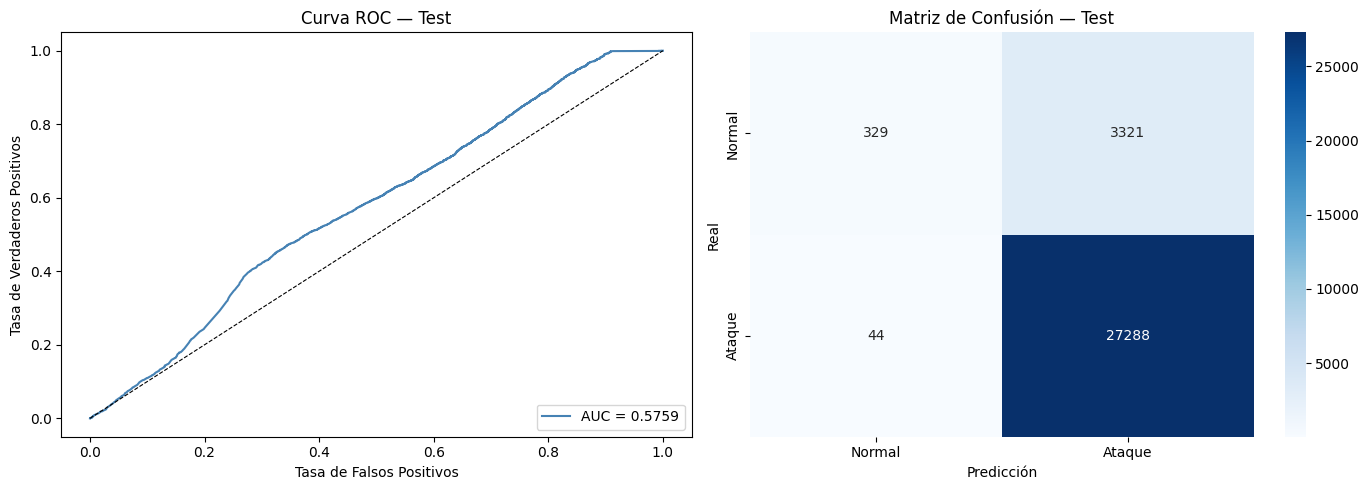

AUC-ROC: 0.5759


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva ROC ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_seq, y_test_prob)
roc_auc     = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='steelblue', lw=1.5, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Test')
axes[0].legend(loc='lower right')

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test_seq, y_test_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Ataque'],
    yticklabels=['Normal', 'Ataque'],
    ax=axes[1]
)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión — Test')

plt.tight_layout()
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")

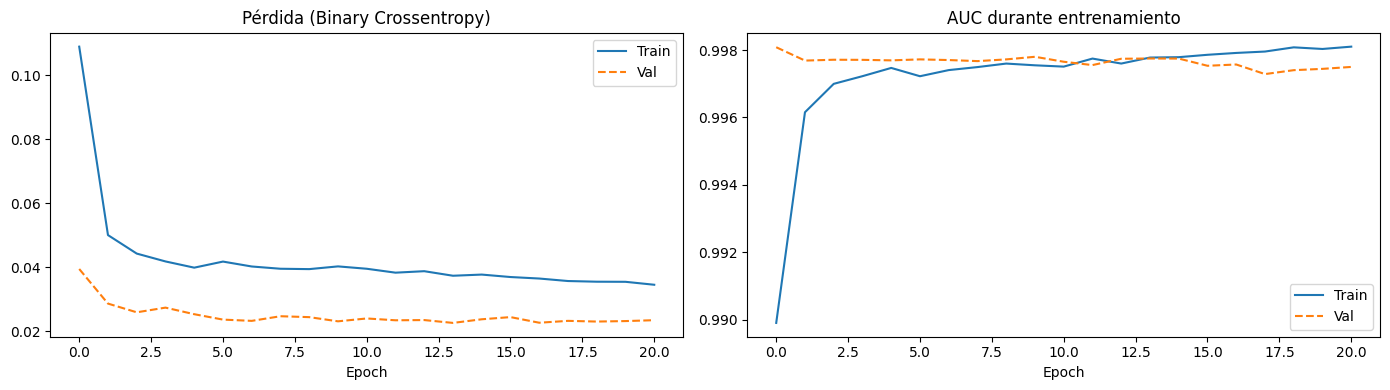

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Pérdida ───────────────────────────────────────────────────────────────────
axes[0].plot(history.history['loss'],     label='Train', lw=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   lw=1.5, linestyle='--')
axes[0].set_title('Pérdida (Binary Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# ── AUC ───────────────────────────────────────────────────────────────────────
axes[1].plot(history.history['auc'],     label='Train', lw=1.5)
axes[1].plot(history.history['val_auc'], label='Val',   lw=1.5, linestyle='--')
axes[1].set_title('AUC durante entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Guardado del modelo

In [17]:
import joblib

# Guardar modelo Keras
model.save("lstm_anomaly_detector.keras")
print("Modelo guardado: lstm_anomaly_detector.keras")

# Guardar scaler y umbral para inferencia futura
joblib.dump(scaler, "robust_scaler.pkl")
joblib.dump(BEST_THRESHOLD, "best_threshold.pkl")
print(f"Scaler guardado: robust_scaler.pkl")
print(f"Umbral guardado: best_threshold.pkl  (θ = {BEST_THRESHOLD:.4f})")

Modelo guardado: lstm_anomaly_detector.keras
Scaler guardado: robust_scaler.pkl
Umbral guardado: best_threshold.pkl  (θ = 0.2024)


## 12. Función de inferencia con forecasting

Recibe un DataFrame con flujos de red en orden temporal y devuelve,
para cada posición `t`, la probabilidad de que el flujo `t + N` sea un ataque.

```
Flujos observados          Predicción
──────────────────         ──────────
[t-9 ... t-1  t0]  →  P(ataque en t0 + N)
[t-8 ... t0   t1]  →  P(ataque en t1 + N)
        ⋮
```

In [18]:
def predecir_anomalias(df_nuevos, modelo, scaler, threshold,
                        time_steps, forecast_n, features):
    """
    Predicción con horizonte temporal (forecasting).

    Parámetros
    ----------
    df_nuevos  : DataFrame con columnas = features, ordenado por tiempo
    modelo     : modelo LSTM entrenado
    scaler     : RobustScaler ajustado en train
    threshold  : umbral óptimo (float)
    time_steps : tamaño de la ventana de contexto
    forecast_n : pasos hacia el futuro que predice el modelo
    features   : lista de nombres de features

    Retorna
    -------
    DataFrame con columnas:
      - t_observado   : índice del último flujo observado en la ventana
      - t_prediccion  : índice del flujo futuro que se está prediciendo
      - probabilidad  : P(ataque) devuelto por el modelo
      - prediccion    : 0=Normal / 1=Ataque
      - clase         : etiqueta legible
    """
    X = (df_nuevos[features]
         .replace([np.inf, -np.inf], np.nan)
         .fillna(df_nuevos[features].median()))
    X_sc = scaler.transform(X)

    limit = len(X_sc) - time_steps - forecast_n + 1
    seqs  = np.array(
        [X_sc[i : i + time_steps] for i in range(limit)],
        dtype=np.float32
    )

    probs = modelo.predict(seqs, batch_size=256, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)

    idx = df_nuevos.index
    resultado = pd.DataFrame({
        't_observado'  : [idx[i + time_steps - 1]      for i in range(limit)],
        't_prediccion' : [idx[i + time_steps + forecast_n - 1] for i in range(limit)],
        'probabilidad' : probs,
        'prediccion'   : preds,
        'clase'        : np.where(preds == 1, 'Ataque', 'Normal'),
    })

    n_ataques = preds.sum()
    print(f"Ventanas analizadas  : {len(preds):,}")
    print(f"Ataques predichos    : {n_ataques:,} ({n_ataques/len(preds):.2%})")
    print(f"Horizonte de pred.   : {forecast_n} flujos hacia el futuro")
    return resultado


# ── Ejemplo: predicción sobre test ───────────────────────────────────────────
df_test_indexed = df_test_raw.reset_index(drop=True)

resultado = predecir_anomalias(
    df_test_indexed,
    model, scaler, BEST_THRESHOLD,
    TIME_STEPS, FORECAST_N, SELECTED_FEATURES
)

print()
resultado.head(10)

Ventanas analizadas  : 30,982
Ataques predichos    : 30,609 (98.80%)
Horizonte de pred.   : 5 flujos hacia el futuro



,t_observado,t_prediccion,probabilidad,prediccion,clase
0,9,14,1.949707e-11,0,Normal
1,10,15,4.858224e-12,0,Normal
2,11,16,1.449721e-02,0,Normal
3,12,17,2.870684e-03,0,Normal
4,13,18,1.120839e-05,0,Normal
5,14,19,2.172112e-02,0,Normal
6,15,20,1.160344e-06,0,Normal
7,16,21,1.491365e-03,0,Normal
8,17,22,1.401706e-06,0,Normal
9,18,23,7.470094e-04,0,Normal


## 13. Visualización de predicciones

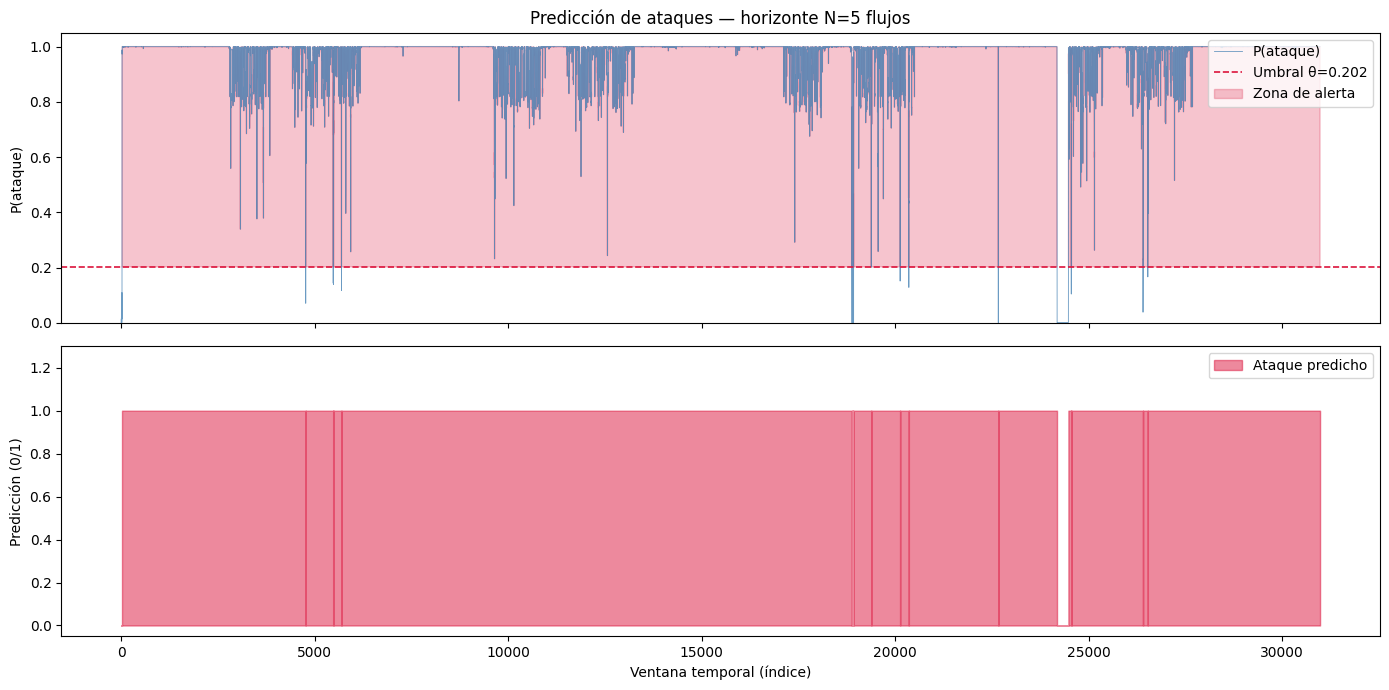


Resumen de predicción con N=5:
clase
Ataque    30609
Normal      373


In [19]:
# ── Visualización: probabilidades de ataque a lo largo del tiempo ────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

idx_plot = np.arange(len(resultado))

# Panel superior: probabilidad continua
axes[0].plot(idx_plot, resultado['probabilidad'],
             lw=0.6, color='steelblue', alpha=0.8, label='P(ataque)')
axes[0].axhline(BEST_THRESHOLD, color='crimson', lw=1.2,
                linestyle='--', label=f'Umbral θ={BEST_THRESHOLD:.3f}')
axes[0].fill_between(idx_plot, resultado['probabilidad'],
                     BEST_THRESHOLD,
                     where=resultado['probabilidad'] >= BEST_THRESHOLD,
                     color='crimson', alpha=0.25, label='Zona de alerta')
axes[0].set_ylabel('P(ataque)')
axes[0].set_title(f'Predicción de ataques — horizonte N={FORECAST_N} flujos')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 1.05)

# Panel inferior: clasificación binaria
axes[1].fill_between(idx_plot, resultado['prediccion'],
                     color='crimson', alpha=0.5, step='mid', label='Ataque predicho')
axes[1].set_ylabel('Predicción (0/1)')
axes[1].set_xlabel('Ventana temporal (índice)')
axes[1].set_ylim(-0.05, 1.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# ── Resumen por horizonte ─────────────────────────────────────────────────────
print(f"\nResumen de predicción con N={FORECAST_N}:")
print(resultado['clase'].value_counts().to_string())

## 14. Análisis de horizontes de predicción

  N= 1 flujos adelante → F1 = 0.9422
  N= 3 flujos adelante → F1 = 0.9420
  N= 5 flujos adelante → F1 = 0.9419
  N=10 flujos adelante → F1 = 0.9417
  N=20 flujos adelante → F1 = 0.9409


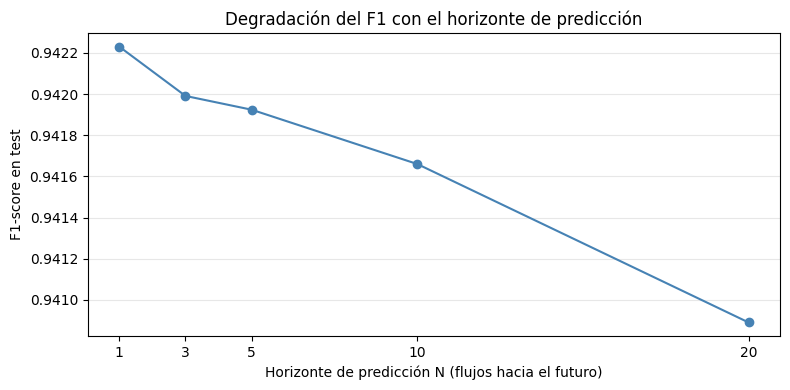


El horizonte óptimo es N=1 con F1=0.9422


In [20]:
# ── Experimento: comparar distintos horizontes de predicción ─────────────────
# Entrena el modelo ya está fijo; aquí solo cambia la construcción del label
# para analizar cómo varía el F1 al predecir más lejos en el futuro.

from sklearn.metrics import f1_score

horizontes = [1, 3, 5, 10, 20]
resultados_n = []

for n in horizontes:
    _, y_t_n = create_sequences(X_test_sc, y_test, TIME_STEPS, forecast_n=n)
    # Recortar las predicciones al mismo tamaño
    largo = min(len(y_test_prob), len(y_t_n))
    y_pred_n = (y_test_prob[:largo] >= BEST_THRESHOLD).astype(int)
    y_true_n = y_t_n[:largo]
    f1 = f1_score(y_true_n, y_pred_n, zero_division=0)
    resultados_n.append({'N': n, 'F1': f1})
    print(f"  N={n:>2} flujos adelante → F1 = {f1:.4f}")

df_n = pd.DataFrame(resultados_n)

plt.figure(figsize=(8, 4))
plt.plot(df_n['N'], df_n['F1'], marker='o', color='steelblue', lw=1.5)
plt.xlabel('Horizonte de predicción N (flujos hacia el futuro)')
plt.ylabel('F1-score en test')
plt.title('Degradación del F1 con el horizonte de predicción')
plt.xticks(horizontes)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEl horizonte óptimo es N={df_n.loc[df_n['F1'].idxmax(), 'N']} "
      f"con F1={df_n['F1'].max():.4f}")